# TS0 – Primeros pasos en simulación

**Materia:** Análisis y Procesamiento de Señales  
**Carrera:** Ingeniería Biomédica – UNSAM  

En este trabajo se implementa un generador de señales senoidales parametrizable en Python utilizando NumPy.

La función desarrollada permite controlar:

- Amplitud máxima
- Valor medio (DC)
- Frecuencia
- Fase
- Cantidad de muestras
- Frecuencia de muestreo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

## Implementación del generador de señales

Se implementa la función `mi_senoidal`, que genera una señal senoidal a partir de los parámetros solicitados en la consigna.

La función devuelve:

- `tt` : vector de tiempo
- `xx` : vector de muestras de la señal

In [2]:
def mi_senoidal(vmax=1, dc=0, ff=1, ph=0, nn=100, fs=1000):

    ts = 1/fs
    tt = np.linspace(0, (nn-1)*ts, nn)

    xx = dc + vmax*np.sin(2*np.pi*ff*tt + ph)

    return tt, xx

In [3]:
fs = 1000     # frecuencia de muestreo
N = 1000      # cantidad de muestras

vmax = 1
dc = 0
ph = 0

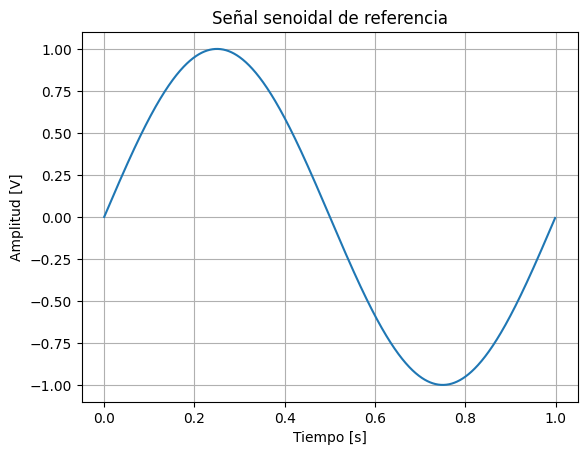

In [4]:
tt, xx = mi_senoidal(vmax, dc, 1, ph, N, fs)

plt.figure()
plt.plot(tt,xx)
plt.title("Señal senoidal de referencia")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()

## Experimentos con distintas frecuencias

Se analiza el comportamiento de la señal muestreada al modificar su frecuencia.

Se utilizan las frecuencias sugeridas en la consigna:

- 500 Hz
- 999 Hz
- 1001 Hz
- 2001 Hz

Esto permite observar efectos asociados al **teorema de Nyquist** y **aliasing**.

### 500 Hz

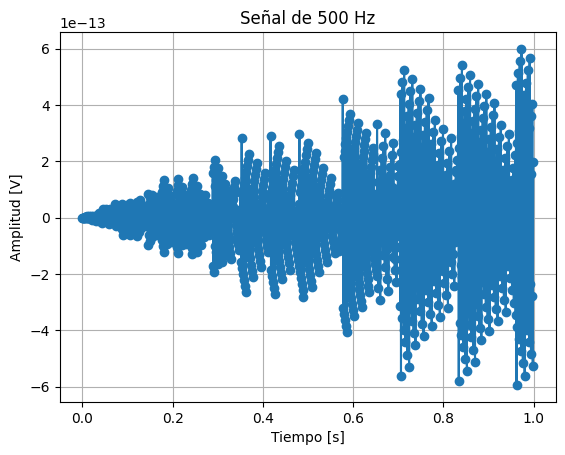

In [5]:
tt, xx = mi_senoidal(vmax, dc, 500, ph, N, fs)

plt.figure()
plt.plot(tt,xx,'o-')
plt.title("Señal de 500 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()

La frecuencia de la señal es igual a la frecuencia de Nyquist (fs/2).  
Esto provoca que la señal tenga muy pocos puntos por período, por lo que su representación resulta pobre.

### 999 Hz

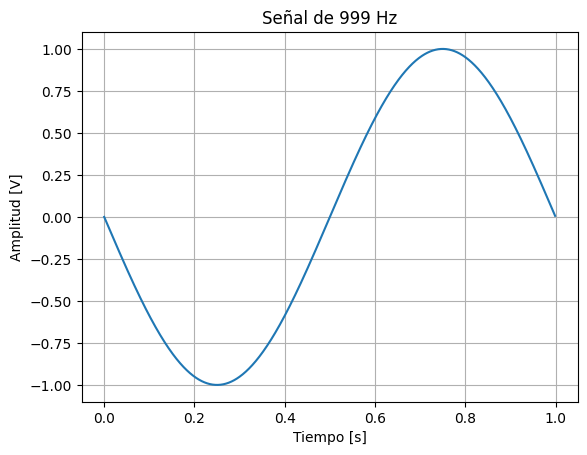

In [6]:
tt, xx = mi_senoidal(vmax, dc, 999, ph, N, fs)

plt.figure()
plt.plot(tt,xx)
plt.title("Señal de 999 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()

La frecuencia es muy cercana a la frecuencia de muestreo.  
Esto genera un efecto de **aliasing**, donde la señal parece tener una frecuencia distinta a la original.

### 1001 Hz

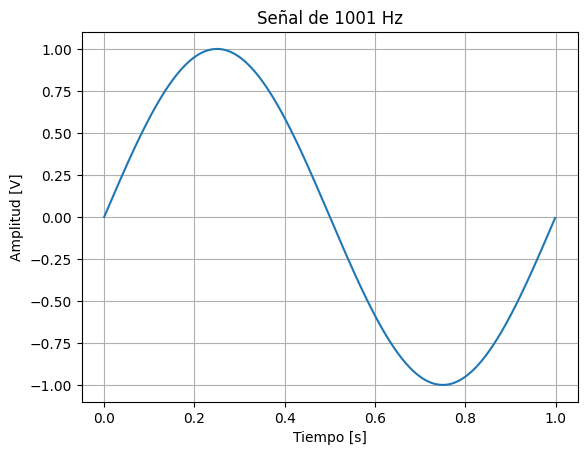

In [7]:
tt, xx = mi_senoidal(vmax, dc, 1001, ph, N, fs)

plt.figure()
plt.plot(tt,xx)
plt.title("Señal de 1001 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()

Al superar la frecuencia de muestreo se produce aliasing, generando una señal aparente con frecuencia diferente.

### 2001 Hz

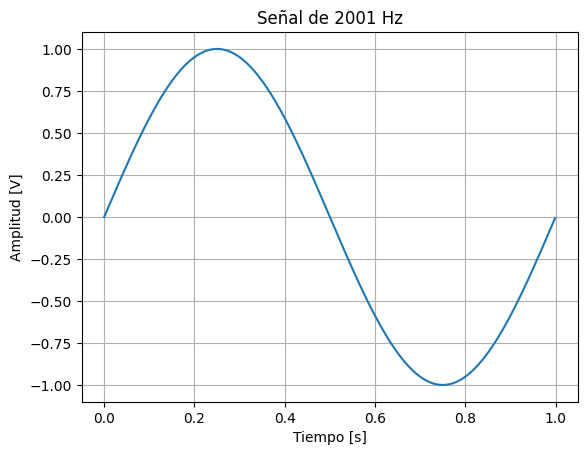

In [8]:
tt, xx = mi_senoidal(vmax, dc, 2001, ph, N, fs)

plt.figure()
plt.plot(tt,xx)
plt.title("Señal de 2001 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()

## Señal adicional – Onda diente de sierra

Como señal adicional se implementa una **onda diente de sierra**, utilizando la librería `scipy.signal`.

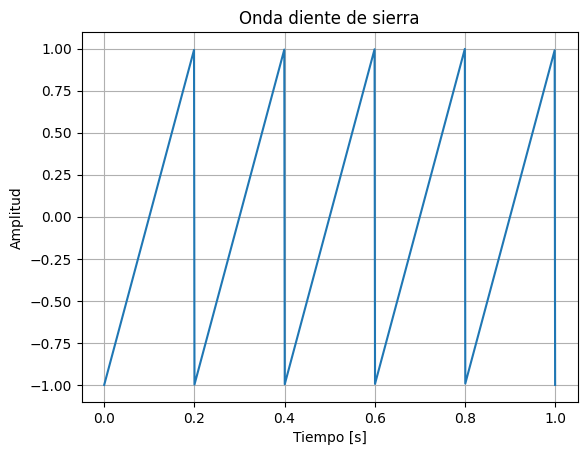

In [9]:
tt = np.linspace(0,1,N)
xx = signal.sawtooth(2*np.pi*5*tt)

plt.figure()
plt.plot(tt,xx)
plt.title("Onda diente de sierra")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

## Cambios respecto a la entrega anterior

En esta nueva entrega se realizaron varias mejoras respecto a la versión presentada en la cursada anterior:

### 1. Implementación de una función reutilizable

En la versión anterior las señales se generaban directamente dentro de cada celda.  
En esta versión se implementó la función `mi_senoidal`, que permite generar señales parametrizando:

- amplitud
- valor medio
- frecuencia
- fase
- cantidad de muestras
- frecuencia de muestreo

Esto mejora la **reutilización y claridad del código**.

---

### 2. Organización del notebook

El notebook fue reorganizado en secciones:

- Importación de librerías
- Implementación del generador
- Definición de parámetros
- Experimentos con distintas frecuencias
- Generación de señales adicionales

Esto facilita la lectura y comprensión del trabajo.

---

### 3. Mejora en la visualización

Se agregaron:

- títulos en los gráficos
- etiquetas de ejes
- grilla

Esto mejora la interpretación de los resultados.

---

### 4. Señales adicionales

Se agregó la generación de una **onda diente de sierra**, extendiendo el generador de señales más allá de la senoidal original.
